# Week 1 Summary — Image Captioning Project (Flickr8k)
### By Aiman Malik

This notebook consolidates the dataset exploration and preprocessing work completed during Week 1.

## 1. Dataset Overview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Dataset load karo
captions_path = "../data/captions.txt"
df = pd.read_csv(captions_path, sep='|')
df.columns = df.columns.str.strip()

print("Dataset Summary:")
print(f"Total images: {df['image_name'].nunique()}")
print(f"Total captions: {df.shape[0]}")
print(f"Captions per image: {df.groupby('image_name').size().iloc[0]}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/captions.txt'

In [2]:
print(os.getcwd())

C:\Users\aiman\Desktop\Internship\Python-Internship


In [3]:
captions_path = "data/captions.txt"
df = pd.read_csv(captions_path, sep='|')
df.columns = df.columns.str.strip()

print("Dataset Summary:")
print(f"Total images: {df['image_name'].nunique()}")
print(f"Total captions: {df.shape[0]}")
print(f"Captions per image: {df.groupby('image_name').size().iloc[0]}")

Dataset Summary:
Total images: 8091
Total captions: 40455
Captions per image: 5


## 2. Caption Statistics

Caption Length Stats:
count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

Vocabulary size (raw, before cleaning): 8918


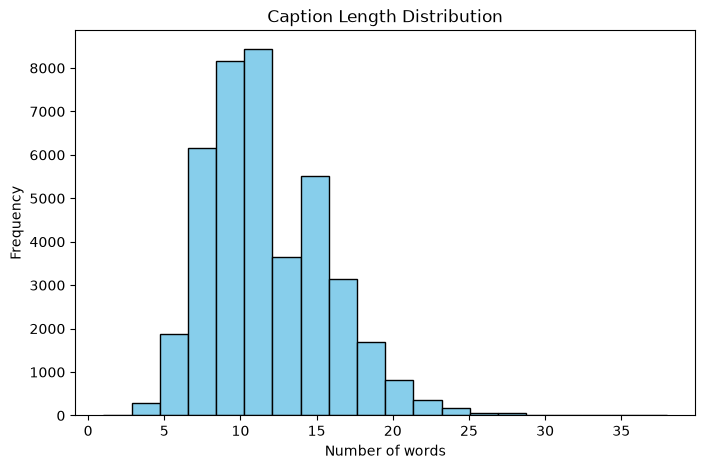

In [4]:
# Caption length
df['caption_length'] = df['caption_text'].apply(lambda x: len(str(x).split()))

print("Caption Length Stats:")
print(df['caption_length'].describe())

# Vocabulary
all_words = []
for caption in df['caption_text']:
    all_words.extend(str(caption).lower().split())
vocab = set(all_words)
print(f"\nVocabulary size (raw, before cleaning): {len(vocab)}")

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['caption_length'], bins=20, color='skyblue', edgecolor='black')
plt.title("Caption Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

## 3. Data Quality Checks

In [5]:
# Duplicate captions
duplicates = df[df.duplicated(subset=['caption_text'], keep=False)]
print(f"Duplicate captions: {duplicates.shape[0]}")

# Short captions
short_captions = df[df['caption_length'] <= 2]
print(f"Short captions (<=2 words): {short_captions.shape[0]}")

# Corrupted images (sample check summary - already verified in Day 2)
print(f"Corrupted images: 0 (verified in Day 2 full check)")

Duplicate captions: 448
Short captions (<=2 words): 17
Corrupted images: 0 (verified in Day 2 full check)


## 4. Preprocessing Summary

**Text Preprocessing:**
- Lowercased all captions
- Removed punctuation using regex
- Tokenized using NLTK's word_tokenize
- Removed English stop-words
- Final cleaned vocabulary: 8,661 unique words

**Image Preprocessing:**
- Verified all images are RGB (3-channel)
- Resized all images to 224x224
- Normalized pixel values to 0-1 range
- Processed images saved to `data/processed/images/`
- Cleaned captions saved to `data/processed/cleaned_captions.csv`

In [7]:
cleaned_df = pd.read_csv("data/processed/cleaned_captions.csv")
print(f"Cleaned captions loaded: {cleaned_df.shape[0]} rows")
cleaned_df.head()


Cleaned captions loaded: 40455 rows


,image_name,caption_number,caption_text,cleaned_caption
0,1000268201_693b08cb0e.jpg,0,A child in a pink dress is climbing up a set o...,child pink dress climbing set stairs entry way
1,1000268201_693b08cb0e.jpg,1,A girl going into a wooden building .,girl going wooden building
2,1000268201_693b08cb0e.jpg,2,A little girl climbing into a wooden playhouse .,little girl climbing wooden playhouse
3,1000268201_693b08cb0e.jpg,3,A little girl climbing the stairs to her playh...,little girl climbing stairs playhouse
4,1000268201_693b08cb0e.jpg,4,A little girl in a pink dress going into a woo...,little girl pink dress going wooden cabin


## 5. Problem Statement

The goal of this project is to build an **Image Captioning System** that automatically generates natural language descriptions for a given image. 

We are using the **Flickr8k dataset**, which contains 8,091 images, each paired with 5 human-written captions (40,455 total captions). This dataset provides diverse, everyday scenes with descriptive captions, making it suitable for training a model to learn the relationship between visual content and language.

The final system will take an image as input and output a coherent, descriptive sentence, similar to the human-written captions in the dataset. This has applications in accessibility (e.g., describing images for visually impaired users), automatic content tagging, and human-computer interaction.